# PHASE 08: MODERN PRETRAINED MODEL STUDY

Phase 08 là phase huấn luyện **2 mô hình học sâu hiện đại** cho yêu cầu đồ án học máy:

1. **MobileNetV2 pretrained**
2. **EfficientNet-B0 pretrained**

Cả hai mô hình đều dùng full train/val/test data và winner strategy đã xác định từ các phase trước:

> WeightedRandomSampler + Light Augmentation + EarlyStopping theo Validation Macro F1

SimpleCNN không còn là mô hình chính ở Phase 08; nó chỉ là baseline/pipeline model ở các phase trước.


# 01. Setup


In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

try:
    from IPython.display import display
except ImportError:
    display = print

def bootstrap_project_dir() -> Path:
    search_roots = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    for root in search_roots:
        candidates = [root, root / 'plan']
        for candidate in candidates:
            if (candidate / 'src').exists():
                if str(candidate) not in sys.path:
                    sys.path.append(str(candidate))
                from src.paths import find_project_dir
                return find_project_dir(candidate)
    raise FileNotFoundError('Không tìm thấy thư mục project plan chứa src/. Hãy chạy notebook từ repo hoặc thư mục plan.')


PROJECT_DIR = bootstrap_project_dir()

from src.data import (
    ProjectPaths,
    ensure_directories,
    load_metadata,
    get_class_counts,
    get_num_classes,
    compute_inverse_frequency_weights,
    build_data_loader,
    build_weighted_sampler,
)
from src.models import get_mobilenet_v2, get_efficientnet_b0
from src.train import train_model, evaluate_model
from src.utils import (
    set_seed,
    get_device,
    get_pin_memory,
    get_num_workers,
    get_basic_transform,
    get_light_augmentation_transform,
    dataframe_to_markdown_safe,
    write_text_report,
)
from src.visualization import set_publication_style, plot_confusion_heatmap

SEED = 42
set_seed(SEED)
set_publication_style()
DEVICE = get_device()
print(f'Thiết bị sử dụng: {DEVICE}')

PATHS = ProjectPaths(PROJECT_DIR)
BASE_DIR = PATHS.base_dir
METADATA_DIR = PATHS.metadata_dir
RESULTS_DIR = PATHS.results_dir('08_modern_pretrained_model_study')
REPORTS_DIR = PATHS.reports_dir('08_modern_pretrained_model_study')
PHASE08_DIR = RESULTS_DIR / 'phase_08_modern_pretrained_models'
PHASE08_FIGURE_DIR = PHASE08_DIR / 'figures'
PHASE08_TABLE_DIR = PHASE08_DIR / 'tables'
PHASE08_REPORT_DIR = PHASE08_DIR / 'reports'
PHASE08_MODEL_DIR = PHASE08_DIR / 'saved_models'
ensure_directories(RESULTS_DIR, REPORTS_DIR, PHASE08_DIR, PHASE08_FIGURE_DIR, PHASE08_TABLE_DIR, PHASE08_REPORT_DIR, PHASE08_MODEL_DIR)

IMAGE_SIZE = 128
NUM_WORKERS = get_num_workers(DEVICE, notebook_safe=True)
PIN_MEMORY = get_pin_memory(DEVICE)
FORCE_TRAIN = True
BATCH_SIZE = 64
EARLY_STOPPING_PATIENCE = 3
FEATURE_EXTRACTION_EPOCHS = 5
FINE_TUNING_EPOCHS = 10
FEATURE_EXTRACTION_LR = 1e-3
FINE_TUNING_LR = 1e-5
DROPOUT_P = 0.2



Thiết bị sử dụng: mps


# 02. Load full train/val/test data


In [2]:
train_df, val_df, test_df, class_map_df = load_metadata(METADATA_DIR)
NUM_CLASSES = get_num_classes(class_map_df=class_map_df)
class_names_list = class_map_df.sort_values('class_id')['class_name'].tolist()

train_counts = get_class_counts(train_df)
imbalance_ratio = train_counts.max() / train_counts.min()
minority_threshold = train_counts.quantile(0.25)
minority_ids = train_counts[train_counts <= minority_threshold].index.tolist()

print('[FULL DATA MODE] Phase 08 dùng toàn bộ train/val/test metadata.')
print(f'Train={len(train_df):,} | Val={len(val_df):,} | Test={len(test_df):,}')
print(f'Num classes={NUM_CLASSES} | Imbalance ratio={imbalance_ratio:.2f}')
print('Minority IDs:', minority_ids)



[FULL DATA MODE] Phase 08 dùng toàn bộ train/val/test metadata.
Train=43,444 | Val=5,430 | Test=5,431
Num classes=38 | Imbalance ratio=36.11
Minority IDs: [0, 1, 2, 7, 14, 17, 22, 23, 27, 36]


# 03. Winner strategy DataLoader


In [ ]:
from torch.utils.data.sampler import WeightedRandomSampler


train_transform = get_light_augmentation_transform(IMAGE_SIZE)
val_test_transform = get_basic_transform(IMAGE_SIZE)
sampler_weights = compute_inverse_frequency_weights(train_counts, num_classes=NUM_CLASSES)

weight_table = pd.DataFrame({
    'class_id': range(NUM_CLASSES),
    'class_name': class_names_list,
    'train_count': [int(train_counts.get(i, 0)) for i in range(NUM_CLASSES)],
    'sampler_weight': sampler_weights,
    'is_minority': [i in minority_ids for i in range(NUM_CLASSES)],
})
weight_table.to_csv(PHASE08_TABLE_DIR / 'phase08_sampler_weights.csv', index=False)
display(weight_table.sort_values('train_count').head(15))


def build_loaders():# -> tuple[DataLoader[Any], DataLoader[Any], DataLoader[Any]]:
    sampler: WeightedRandomSampler = build_weighted_sampler(train_df, sampler_weights, replacement=True)
    train_loader = build_data_loader(
        train_df, BASE_DIR, 'color', train_transform,
        batch_size=BATCH_SIZE,
        shuffle=False,
        sampler=sampler,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
    )
    val_loader = build_data_loader(val_df, BASE_DIR, 'color', val_test_transform, BATCH_SIZE, False, None, NUM_WORKERS, PIN_MEMORY)
    test_loader = build_data_loader(test_df, BASE_DIR, 'color', val_test_transform, BATCH_SIZE, False, None, NUM_WORKERS, PIN_MEMORY)
    return train_loader, val_loader, test_loader



,class_id,class_name,train_count,sampler_weight,is_minority
22,22,Potato___healthy,122,5.154913,True
2,2,Apple___Cedar_apple_rust,220,2.858634,True
17,17,Peach___healthy,288,2.183679,True
23,23,Raspberry___healthy,297,2.117507,True
36,36,Tomato___Tomato_mosaic_virus,298,2.110401,True
14,14,Grape___healthy,338,1.860649,True
27,27,Strawberry___healthy,365,1.723012,True
7,7,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,410,1.533901,True
1,1,Apple___Black_rot,497,1.265391,True
0,0,Apple___Apple_scab,504,1.247816,True


# 04. Model factory và two-stage training


In [4]:
def build_modern_model(model_name):
    if model_name == 'mobilenetv2':
        return get_mobilenet_v2(num_classes=NUM_CLASSES, freeze_features=True, dropout_p=DROPOUT_P)
    if model_name == 'efficientnet_b0':
        return get_efficientnet_b0(num_classes=NUM_CLASSES, freeze_features=True, dropout_p=DROPOUT_P)
    raise ValueError(model_name)


def set_backbone_trainable(model, trainable):
    for parameter in model.features.parameters():
        parameter.requires_grad = trainable


def count_parameters(model, trainable_only=False):
    params = model.parameters()
    if trainable_only:
        params = [p for p in model.parameters() if p.requires_grad]
    return sum(p.numel() for p in params)


def merge_histories(stage1, stage2):
    merged = {}
    for key in ['train_loss', 'val_loss', 'val_f1', 'val_acc']:
        merged[key] = stage1.get(key, []) + stage2.get(key, [])
    merged['stage'] = ['feature_extraction'] * len(stage1.get('train_loss', [])) + ['fine_tuning'] * len(stage2.get('train_loss', []))
    return merged



# 05. Experiment design


In [5]:
EXPERIMENTS = [
    {
        'name': 'mobilenetv2_winner',
        'model_name': 'mobilenetv2',
        'description': 'MobileNetV2 pretrained + WeightedRandomSampler + Light Augmentation + EarlyStopping',
    },
    {
        'name': 'efficientnet_b0_winner',
        'model_name': 'efficientnet_b0',
        'description': 'EfficientNet-B0 pretrained + WeightedRandomSampler + Light Augmentation + EarlyStopping',
    },
]

design_df = pd.DataFrame(EXPERIMENTS)
design_df.to_csv(PHASE08_TABLE_DIR / 'phase08_modern_model_design.csv', index=False)
display(design_df)



,name,model_name,description
0,mobilenetv2_winner,mobilenetv2,MobileNetV2 pretrained + WeightedRandomSampler...
1,efficientnet_b0_winner,efficientnet_b0,EfficientNet-B0 pretrained + WeightedRandomSam...


# 06. Run one experiment


In [6]:
modern_results = {}
modern_histories = {}


def train_two_stage(model, experiment_name, train_loader, val_loader):
    criterion = nn.CrossEntropyLoss()
    stage1_path = PHASE08_MODEL_DIR / f'{experiment_name}_{IMAGE_SIZE}px_stage1.pth'
    final_path = PHASE08_MODEL_DIR / f'{experiment_name}_{IMAGE_SIZE}px_best.pth'

    set_backbone_trainable(model, False)
    optimizer1 = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=FEATURE_EXTRACTION_LR)
    print(f'Stage 1 trainable params: {count_parameters(model, True):,}')
    stage1 = train_model(model, train_loader, val_loader, criterion, optimizer1, FEATURE_EXTRACTION_EPOCHS, DEVICE, stage1_path, EARLY_STOPPING_PATIENCE, True)
    model.load_state_dict(torch.load(stage1_path, map_location=DEVICE))

    set_backbone_trainable(model, True)
    optimizer2 = optim.Adam(model.parameters(), lr=FINE_TUNING_LR)
    print(f'Stage 2 trainable params: {count_parameters(model, True):,}')
    stage2 = train_model(model, train_loader, val_loader, criterion, optimizer2, FINE_TUNING_EPOCHS, DEVICE, final_path, EARLY_STOPPING_PATIENCE, True)
    model.load_state_dict(torch.load(final_path, map_location=DEVICE))
    return model, merge_histories(stage1, stage2)


def run_experiment(config):
    set_seed(SEED)
    train_loader, val_loader, test_loader = build_loaders()
    name = config['name']
    model = build_modern_model(config['model_name']).to(DEVICE)
    final_path = PHASE08_MODEL_DIR / f'{name}_{IMAGE_SIZE}px_best.pth'

    print('\n' + '=' * 80)
    print(f'MODERN MODEL EXPERIMENT: {name}')
    print(config['description'])
    print('=' * 80)
    print(f'Total params: {count_parameters(model):,}')

    if (not FORCE_TRAIN) and final_path.exists():
        set_backbone_trainable(model, True)
        model.load_state_dict(torch.load(final_path, map_location=DEVICE))
        history = None
    else:
        model, history = train_two_stage(model, name, train_loader, val_loader)
        modern_histories[name] = history
        pd.DataFrame(history).to_csv(PHASE08_TABLE_DIR / f'{name}_training_history.csv', index=False)

    result = evaluate_model(model, test_loader, DEVICE, num_classes=NUM_CLASSES)
    modern_results[name] = result

    pd.DataFrame({'true_label': result['labels'], 'predicted_label': result['preds']}).to_csv(PHASE08_TABLE_DIR / f'{name}_predictions.csv', index=False)
    per_class_df = pd.DataFrame({
        'Experiment': name,
        'Class_ID': range(NUM_CLASSES),
        'Class': class_names_list,
        'Train Sample Count': [int(train_counts.get(i, 0)) for i in range(NUM_CLASSES)],
        'Is Minority': [i in minority_ids for i in range(NUM_CLASSES)],
        'Recall': result['per_class_recall'],
        'F1-score': result['per_class_f1'],
    })
    per_class_df.to_csv(PHASE08_TABLE_DIR / f'{name}_per_class_metrics.csv', index=False)

    plot_confusion_heatmap(result['labels'], result['preds'], labels=list(range(NUM_CLASSES)), normalize='true', title=f'Normalized Confusion Matrix - {name}', save_path=PHASE08_FIGURE_DIR / f'{name}_confusion_matrix_normalized.png', figsize=(18, 15))
    print(f"[RESULT {name}] Acc={result['accuracy']:.4f} | Macro F1={result['macro_f1']:.4f}")
    return result



# 07. Run MobileNetV2 and EfficientNet-B0



MODERN MODEL EXPERIMENT: mobilenetv2_winner
MobileNetV2 pretrained + WeightedRandomSampler + Light Augmentation + EarlyStopping
Total params: 2,272,550
Stage 1 trainable params: 48,678
Epoch 01/05 | Train Loss: 0.8116 | Val Loss: 0.3749 | Val Acc: 0.8980 | Val Macro F1: 0.8765
Epoch 02/05 | Train Loss: 0.3654 | Val Loss: 0.2726 | Val Acc: 0.9208 | Val Macro F1: 0.9037
Epoch 03/05 | Train Loss: 0.3057 | Val Loss: 0.2409 | Val Acc: 0.9297 | Val Macro F1: 0.9139
Epoch 04/05 | Train Loss: 0.2728 | Val Loss: 0.2340 | Val Acc: 0.9284 | Val Macro F1: 0.9131
Epoch 05/05 | Train Loss: 0.2662 | Val Loss: 0.2113 | Val Acc: 0.9319 | Val Macro F1: 0.9136
Stage 2 trainable params: 2,272,550
Epoch 01/10 | Train Loss: 0.2307 | Val Loss: 0.1716 | Val Acc: 0.9495 | Val Macro F1: 0.9371
Epoch 02/10 | Train Loss: 0.1738 | Val Loss: 0.1415 | Val Acc: 0.9558 | Val Macro F1: 0.9465
Epoch 03/10 | Train Loss: 0.1361 | Val Loss: 0.1183 | Val Acc: 0.9639 | Val Macro F1: 0.9579
Epoch 04/10 | Train Loss: 0.1166 |

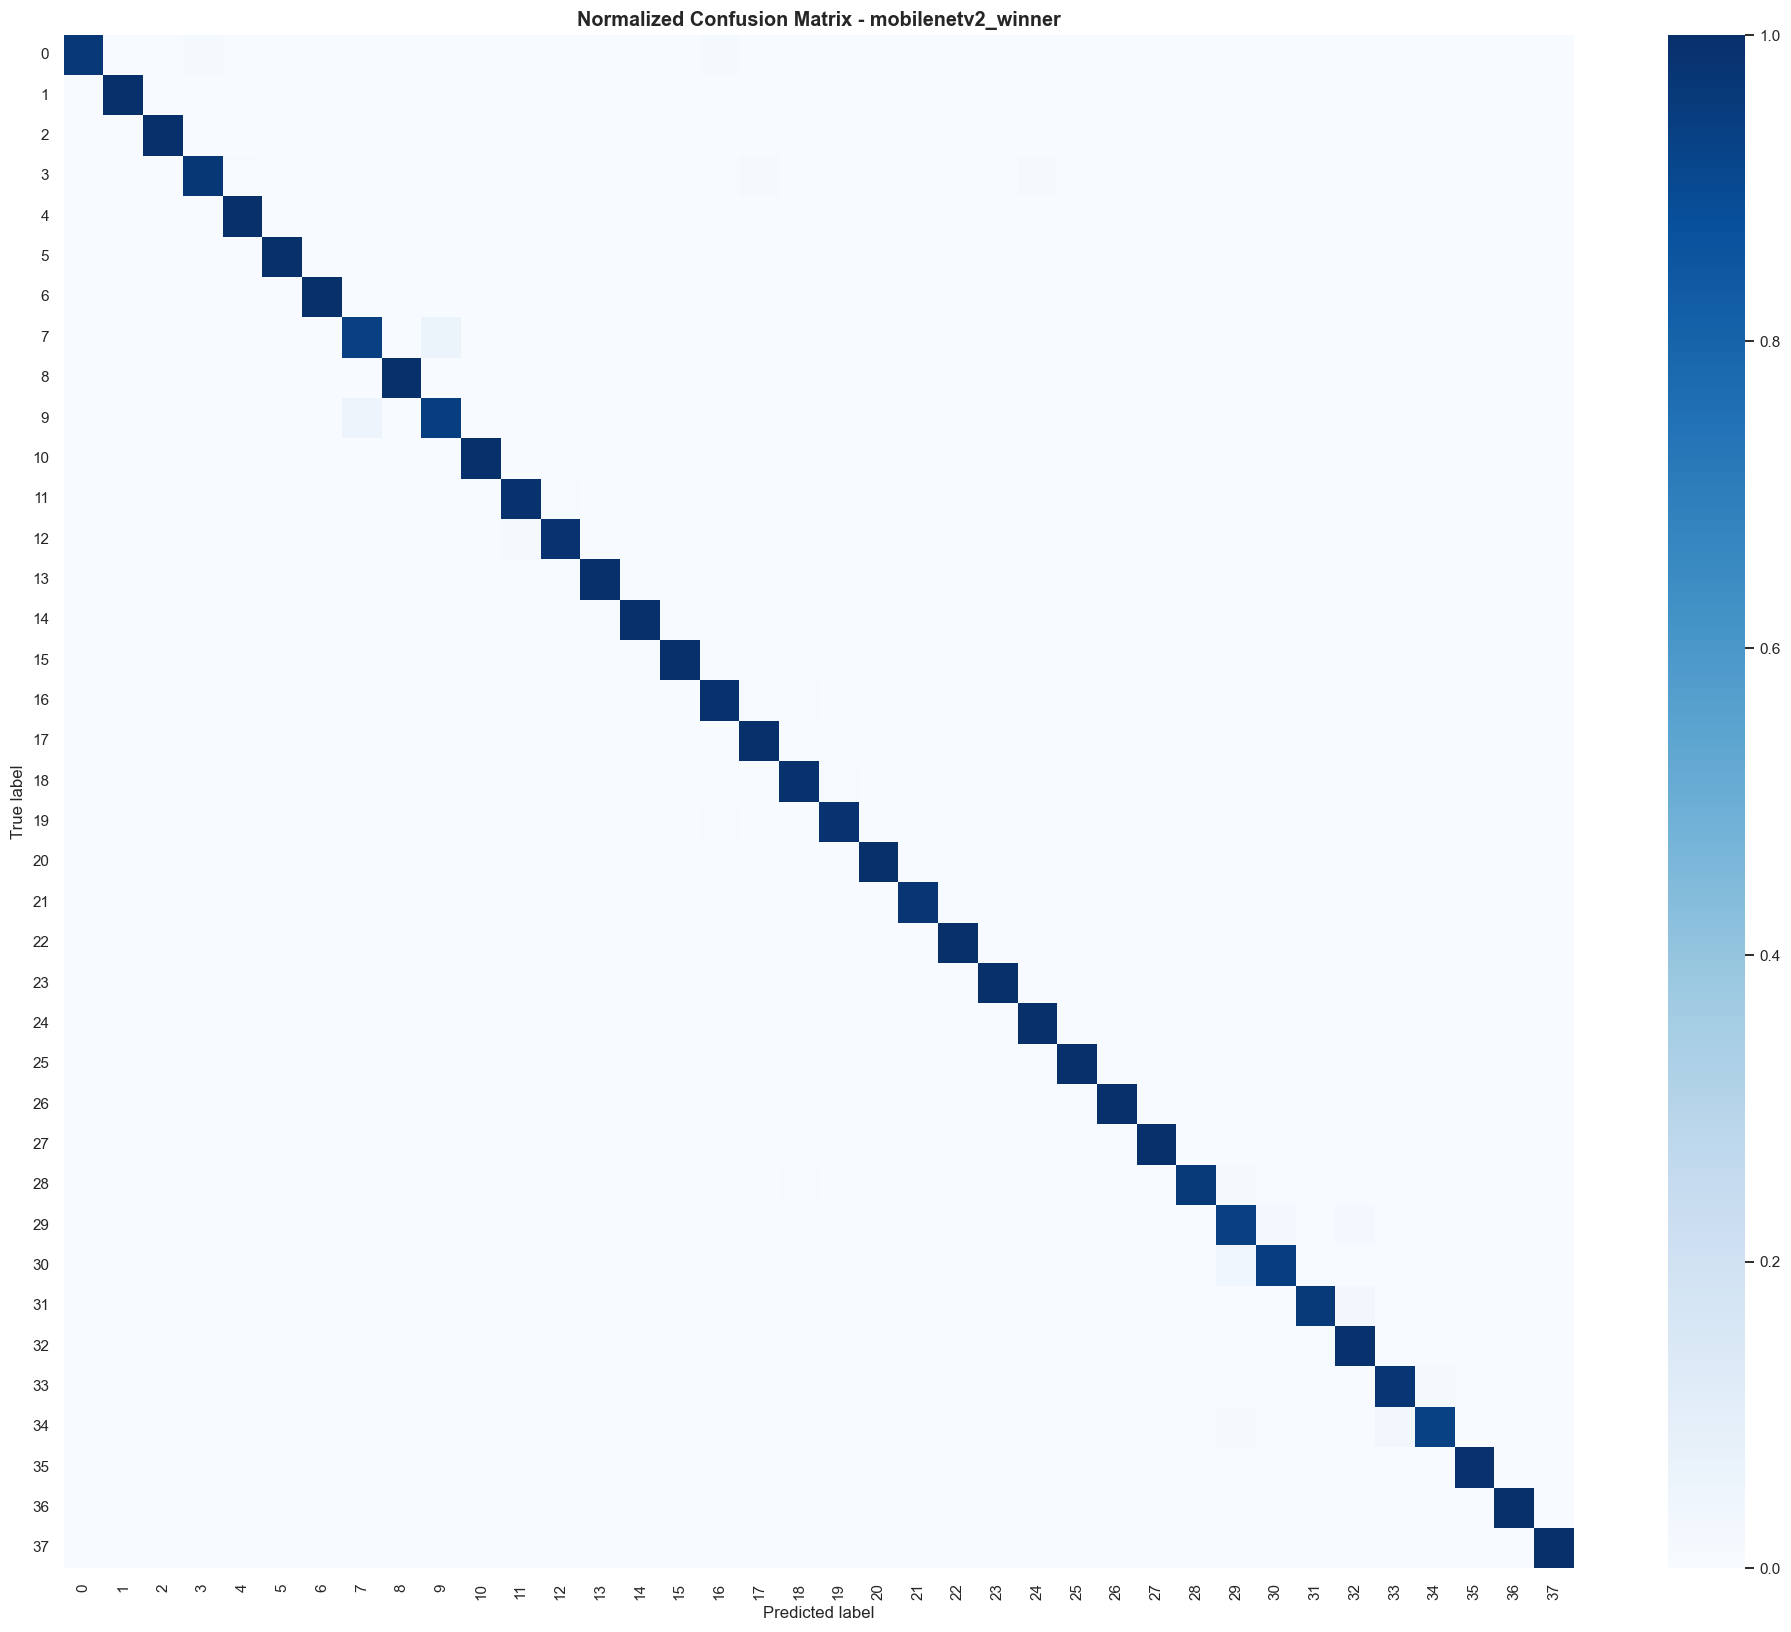

[RESULT mobilenetv2_winner] Acc=0.9866 | Macro F1=0.9829

MODERN MODEL EXPERIMENT: efficientnet_b0_winner
EfficientNet-B0 pretrained + WeightedRandomSampler + Light Augmentation + EarlyStopping
Total params: 4,056,226
Stage 1 trainable params: 48,678
Epoch 01/05 | Train Loss: 0.9020 | Val Loss: 0.4673 | Val Acc: 0.8783 | Val Macro F1: 0.8493
Epoch 02/05 | Train Loss: 0.4597 | Val Loss: 0.3594 | Val Acc: 0.8976 | Val Macro F1: 0.8755
Epoch 03/05 | Train Loss: 0.3994 | Val Loss: 0.3130 | Val Acc: 0.9083 | Val Macro F1: 0.8849
Epoch 04/05 | Train Loss: 0.3671 | Val Loss: 0.2949 | Val Acc: 0.9114 | Val Macro F1: 0.8884
Epoch 05/05 | Train Loss: 0.3567 | Val Loss: 0.2924 | Val Acc: 0.9077 | Val Macro F1: 0.8820
Stage 2 trainable params: 4,056,226
Epoch 01/10 | Train Loss: 0.2858 | Val Loss: 0.2051 | Val Acc: 0.9368 | Val Macro F1: 0.9181
Epoch 02/10 | Train Loss: 0.2074 | Val Loss: 0.1536 | Val Acc: 0.9529 | Val Macro F1: 0.9367
Epoch 03/10 | Train Loss: 0.1653 | Val Loss: 0.1273 | Val Acc:

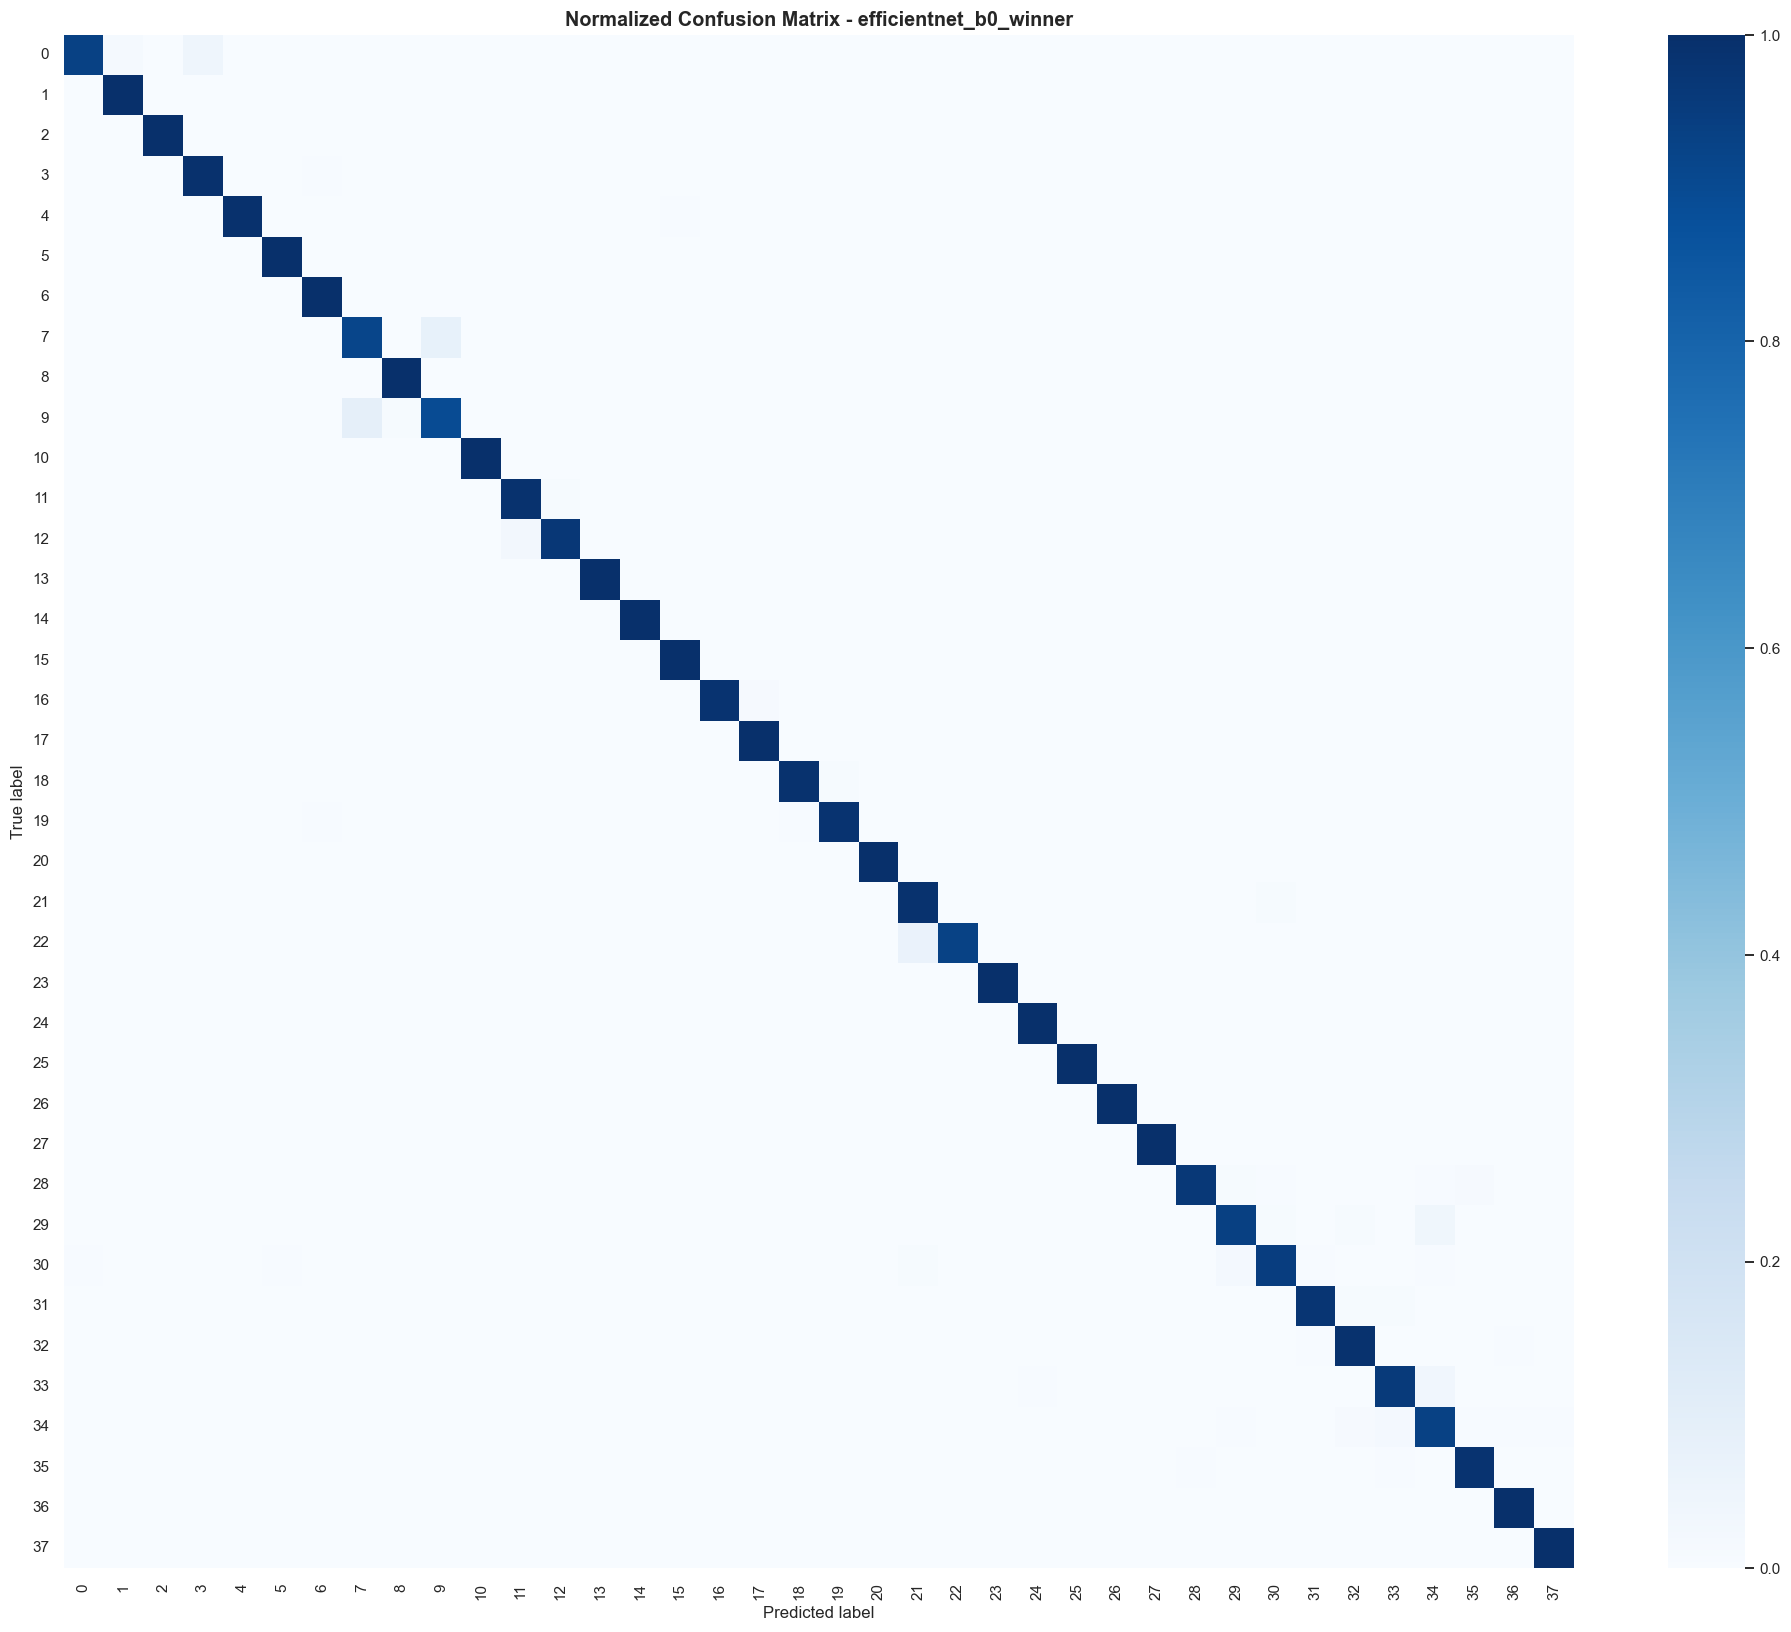

[RESULT efficientnet_b0_winner] Acc=0.9842 | Macro F1=0.9796


In [7]:
for config in EXPERIMENTS:
    run_experiment(config)



# 08. Compare modern models


,Experiment,Model,Params,Accuracy,Macro Precision,Macro Recall,Macro F1,Minority Recall,Worst-class Recall
0,mobilenetv2_winner,mobilenetv2,2272550,0.986559,0.980589,0.985519,0.982922,0.990943,0.936170
1,efficientnet_b0_winner,efficientnet_b0,4056226,0.984165,0.978211,0.981341,0.979556,0.979141,0.897959


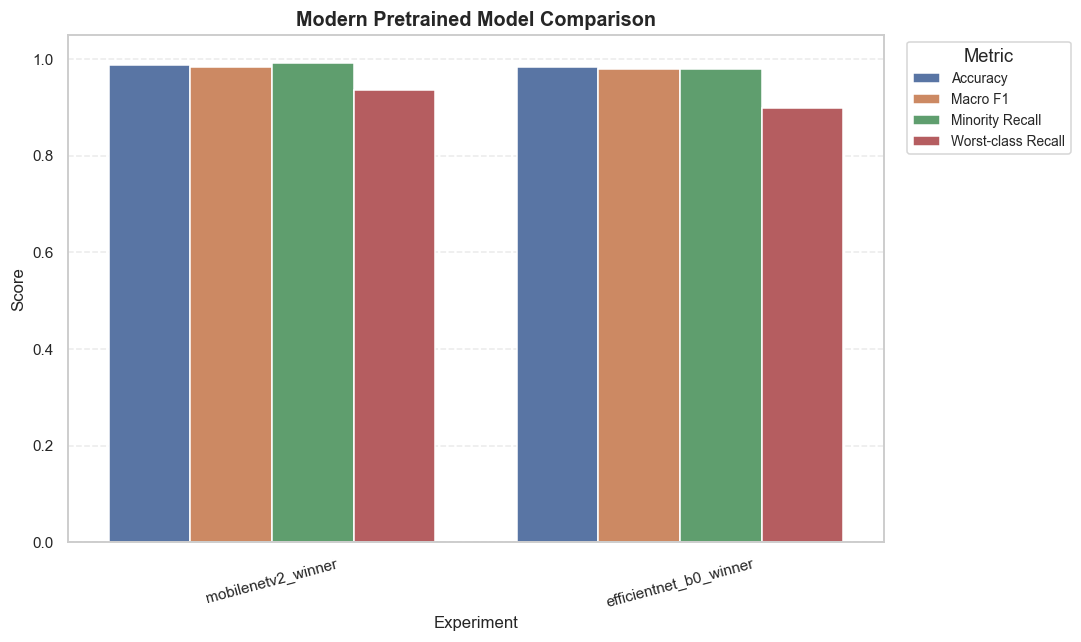

In [8]:
def summarize(results):
    rows = []
    for name, result in results.items():
        model = build_modern_model(next(c['model_name'] for c in EXPERIMENTS if c['name'] == name))
        rows.append({
            'Experiment': name,
            'Model': next(c['model_name'] for c in EXPERIMENTS if c['name'] == name),
            'Params': count_parameters(model),
            'Accuracy': result['accuracy'],
            'Macro Precision': result['precision'],
            'Macro Recall': result['recall'],
            'Macro F1': result['macro_f1'],
            'Minority Recall': np.mean([result['per_class_recall'][i] for i in minority_ids]),
            'Worst-class Recall': np.min(result['per_class_recall']),
        })
    return pd.DataFrame(rows).sort_values('Macro F1', ascending=False).reset_index(drop=True)

summary_df = summarize(modern_results)
summary_df.to_csv(PHASE08_TABLE_DIR / 'phase08_modern_model_comparison.csv', index=False)
display(summary_df)

plot_df = summary_df.melt(id_vars='Experiment', value_vars=['Accuracy', 'Macro F1', 'Minority Recall', 'Worst-class Recall'], var_name='Metric', value_name='Score')
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=plot_df, x='Experiment', y='Score', hue='Metric')
ax.set_title('Modern Pretrained Model Comparison', fontweight='bold')
ax.set_ylim(0, 1.05)
ax.tick_params(axis='x', rotation=15)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend(title='Metric', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig(PHASE08_FIGURE_DIR / 'phase08_modern_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()



# 09. Report export


In [9]:
best_row = summary_df.iloc[0]
report_sections = []
report_sections.append('# Phase 08 Report: Modern Pretrained Model Study')
report_sections.append('')
report_sections.append('Phase 08 huấn luyện hai mô hình học sâu hiện đại chính của đồ án: MobileNetV2 pretrained và EfficientNet-B0 pretrained.')
report_sections.append('')
report_sections.append('## Comparison')
report_sections.append(dataframe_to_markdown_safe(summary_df))
report_sections.append('')
report_sections.append('## Conclusion')
report_sections.append(f"Mô hình tốt nhất theo Macro F1 là `{best_row['Experiment']}` với Macro F1 = {best_row['Macro F1']:.4f}, Minority Recall = {best_row['Minority Recall']:.4f}.")

write_text_report(PHASE08_REPORT_DIR / 'phase08_modern_model_report.md', report_sections)
write_text_report(PHASE08_REPORT_DIR / 'phase08_modern_model_report.txt', report_sections)
print('\n'.join(report_sections))



# Phase 08 Report: Modern Pretrained Model Study

Phase 08 huấn luyện hai mô hình học sâu hiện đại chính của đồ án: MobileNetV2 pretrained và EfficientNet-B0 pretrained.

## Comparison
            Experiment           Model  Params  Accuracy  Macro Precision  Macro Recall  Macro F1  Minority Recall  Worst-class Recall
    mobilenetv2_winner     mobilenetv2 2272550  0.986559         0.980589      0.985519  0.982922         0.990943            0.936170
efficientnet_b0_winner efficientnet_b0 4056226  0.984165         0.978211      0.981341  0.979556         0.979141            0.897959

## Conclusion
Mô hình tốt nhất theo Macro F1 là `mobilenetv2_winner` với Macro F1 = 0.9829, Minority Recall = 0.9909.
